In [1]:
import os, random, numpy as np, pandas as pd
import torch, torch.nn as nn, torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms
from PIL import Image
from sklearn.metrics import balanced_accuracy_score, f1_score, classification_report

def set_seed(s=42):
    random.seed(s); np.random.seed(s); torch.manual_seed(s)
set_seed(42)

DEVICE = torch.device("cpu")
DATA_DIR   = os.path.join("..","data")
IMAGES_DIR = os.path.join(DATA_DIR, "HAM_10000_images")
META_CSV   = os.path.join(DATA_DIR, "HAM10000_metadata.csv")
SPLIT_CSV  = "ham10000_split_v2.csv"   # <- το καλό split (≈8000/1000/1000)

assert os.path.exists(SPLIT_CSV), "Λείπει το ham10000_split_v2.csv"
assert os.path.isdir(IMAGES_DIR),  "Δεν βρέθηκε ο φάκελος εικόνων"
assert os.path.exists(META_CSV),   "Λείπει το metadata CSV"

split = pd.read_csv(SPLIT_CSV)
print(split["split"].value_counts())  # περιμένω ~8000/1000/1000

CLASS_NAMES = ['akiec','bcc','bkl','df','mel','nv','vasc']
class_to_idx = {c:i for i,c in enumerate(CLASS_NAMES)}


split
train    8001
val      1009
test     1005
Name: count, dtype: int64


In [2]:
meta = pd.read_csv(META_CSV)
meta['filename'] = meta['image_id'] + ".jpg"
meta['filepath'] = meta['filename'].apply(lambda x: os.path.join(IMAGES_DIR, x))
df = meta.merge(split, on=['image_id','lesion_id','dx'], how='inner')

df_train = df[df.split=='train'].reset_index(drop=True)
df_val   = df[df.split=='val'  ].reset_index(drop=True)
df_test  = df[df.split=='test' ].reset_index(drop=True)
len(df_train), len(df_val), len(df_test)


(8001, 1009, 1005)

In [3]:
IMG = 224
IMNET_MEAN = [0.485, 0.456, 0.406]
IMNET_STD  = [0.229, 0.224, 0.225]

train_tfms = transforms.Compose([
    transforms.RandomResizedCrop(IMG, scale=(0.7,1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(180),
    transforms.ColorJitter(brightness=0.15, contrast=0.15),
    transforms.ToTensor(),
    transforms.Normalize(IMNET_MEAN, IMNET_STD),
])
eval_tfms = transforms.Compose([
    transforms.Resize(IMG+32),
    transforms.CenterCrop(IMG),
    transforms.ToTensor(),
    transforms.Normalize(IMNET_MEAN, IMNET_STD),
])

class SkinDS(Dataset):
    def __init__(self, df, tfm): self.df=df.reset_index(drop=True); self.tfm=tfm
    def __len__(self): return len(self.df)
    def __getitem__(self,i):
        r=self.df.iloc[i]; x=Image.open(r['filepath']).convert('RGB')
        return self.tfm(x), class_to_idx[r['dx']], r['image_id']

train_ds, val_ds, test_ds = SkinDS(df_train, train_tfms), SkinDS(df_val, eval_tfms), SkinDS(df_test, eval_tfms)

# ήπιος weighted sampler (για ανισορροπία)
counts = df_train['dx'].value_counts().to_dict()
w_per_class = {c: 1.0/np.log(1.02 + counts[c]) for c in counts}
sample_w = df_train['dx'].map(w_per_class).values
sampler = WeightedRandomSampler(sample_w, num_samples=len(sample_w), replacement=True)

BATCH=16  # CPU-friendly
train_dl = DataLoader(train_ds, batch_size=BATCH, sampler=sampler, num_workers=0)
val_dl   = DataLoader(val_ds,   batch_size=BATCH, shuffle=False, num_workers=0)
test_dl  = DataLoader(test_ds,  batch_size=BATCH, shuffle=False, num_workers=0)


In [4]:
from torchvision.models import mobilenet_v3_small, MobileNet_V3_Small_Weights

try:
    weights = MobileNet_V3_Small_Weights.DEFAULT
    base = mobilenet_v3_small(weights=weights)
except Exception:
    base = mobilenet_v3_small(pretrained=True)

in_features = base.classifier[-1].in_features
base.classifier[-1] = nn.Linear(in_features, len(CLASS_NAMES))
model = base.to(DEVICE)

cnt = df_train['dx'].value_counts().reindex(CLASS_NAMES).values.astype(np.float32)
w = 1.0/np.log(1.02 + cnt)
class_weights = torch.tensor(w, dtype=torch.float32, device=DEVICE)

try:
    criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.05)
except TypeError:
    criterion = nn.CrossEntropyLoss(weight=class_weights)


In [5]:
def run_epoch(dl, train=False, opt=None, sch=None):
    model.train(train)
    tot, y_true, y_pred = 0.0, [], []
    for xb, yb, _ in dl:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        if train: opt.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        if train:
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
            if sch: sch.step()
        tot += loss.item()*xb.size(0)
        y_true += yb.cpu().tolist(); y_pred += logits.argmax(1).cpu().tolist()
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    n=len(dl.dataset)
    acc=(y_true==y_pred).mean()
    bal=balanced_accuracy_score(y_true,y_pred)
    f1 =f1_score(y_true,y_pred,average='macro')
    return tot/n, acc, bal, f1

CKPT = "best_mbv3_tl.pt"; best_f1 = -1.0

# Stage-1: freeze backbone
for p in model.features.parameters(): p.requires_grad=False
opt = optim.AdamW(filter(lambda p:p.requires_grad, model.parameters()), lr=3e-3, weight_decay=1e-4)
sch = optim.lr_scheduler.OneCycleLR(opt, max_lr=3e-3, epochs=5, steps_per_epoch=len(train_dl),
                                    pct_start=0.3, div_factor=10.0, final_div_factor=100.0)
for ep in range(1, 5+1):
    tr = run_epoch(train_dl, True, opt, sch)
    va = run_epoch(val_dl,   False)
    if va[3] > best_f1: best_f1=va[3]; torch.save(model.state_dict(), CKPT); mark="✓"
    else: mark=" "
    print(f"[Head] ep{ep:02d} | tr acc {tr[1]:.3f} f1 {tr[3]:.3f} | val acc {va[1]:.3f} bal {va[2]:.3f} f1 {va[3]:.3f} {mark}")

# Stage-2: unfreeze, fine-tune
for p in model.parameters(): p.requires_grad=True
opt = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
sch = optim.lr_scheduler.OneCycleLR(opt, max_lr=1e-3, epochs=25, steps_per_epoch=len(train_dl),
                                    pct_start=0.3, div_factor=10.0, final_div_factor=100.0)
for ep in range(1, 25+1):
    tr = run_epoch(train_dl, True, opt, sch)
    va = run_epoch(val_dl,   False)
    if va[3] > best_f1: best_f1=va[3]; torch.save(model.state_dict(), CKPT); mark="✓"
    else: mark=" "
    print(f"[FT  ] ep{ep:02d} | tr acc {tr[1]:.3f} f1 {tr[3]:.3f} | val acc {va[1]:.3f} bal {va[2]:.3f} f1 {va[3]:.3f} {mark}")


[Head] ep01 | tr acc 0.658 f1 0.402 | val acc 0.693 bal 0.399 f1 0.406 ✓
[Head] ep02 | tr acc 0.660 f1 0.422 | val acc 0.725 bal 0.366 f1 0.373  
[Head] ep03 | tr acc 0.676 f1 0.466 | val acc 0.694 bal 0.460 f1 0.435 ✓
[Head] ep04 | tr acc 0.706 f1 0.519 | val acc 0.731 bal 0.459 f1 0.459 ✓
[Head] ep05 | tr acc 0.733 f1 0.572 | val acc 0.724 bal 0.483 f1 0.467 ✓
[FT  ] ep01 | tr acc 0.745 f1 0.622 | val acc 0.755 bal 0.558 f1 0.545 ✓
[FT  ] ep02 | tr acc 0.777 f1 0.666 | val acc 0.774 bal 0.539 f1 0.533  
[FT  ] ep03 | tr acc 0.775 f1 0.687 | val acc 0.770 bal 0.593 f1 0.579 ✓
[FT  ] ep04 | tr acc 0.786 f1 0.706 | val acc 0.782 bal 0.563 f1 0.558  
[FT  ] ep05 | tr acc 0.785 f1 0.695 | val acc 0.784 bal 0.574 f1 0.548  
[FT  ] ep06 | tr acc 0.795 f1 0.711 | val acc 0.756 bal 0.564 f1 0.546  
[FT  ] ep07 | tr acc 0.793 f1 0.706 | val acc 0.722 bal 0.567 f1 0.463  
[FT  ] ep08 | tr acc 0.803 f1 0.725 | val acc 0.725 bal 0.501 f1 0.448  
[FT  ] ep09 | tr acc 0.811 f1 0.741 | val acc 0.800

In [6]:
import os

print("📂 current folder:", os.getcwd())
print("\n🔎 .pt / .pth in current folder:")
for f in os.listdir():
    if f.endswith(".pt") or f.endswith(".pth"):
        print("  -", f)

print("\n🔎 .pt / .pth in parent folder:")
for f in os.listdir(".."):
    if f.endswith(".pt") or f.endswith(".pth"):
        print("  - ..\\" + f)


📂 current folder: C:\Users\Common\Documents\skin-lesion-classification\notebooks

🔎 .pt / .pth in current folder:
  - best_mbv3_tl.pt
  - best_tinydermnet_v2.pt

🔎 .pt / .pth in parent folder:


In [7]:
import torch

DEVICE = torch.device("cpu")

# 👉 βάλε ΕΔΩ το όνομα του αρχείου που είδες ότι υπάρχει στον φάκελο
CKPT = "best_mbv3_tl.pt"

# ΠΡΟΣΟΧΗ: πριν το load πρέπει να έχεις ξαναφτιάξει το μοντέλο σου,
# δηλαδή το mobilenetv3 + το δικό σου classifier head,
# όπως το είχες στο training.
# π.χ. κάτι σαν:
# model = create_model(num_classes=len(CLASS_NAMES)).to(DEVICE)

model.load_state_dict(torch.load(CKPT, map_location=DEVICE))
model.to(DEVICE)
model.eval()
print("✅ loaded:", CKPT)


✅ loaded: best_mbv3_tl.pt


In [8]:
import numpy as np
from sklearn.metrics import classification_report, balanced_accuracy_score, f1_score

model.eval()
y_true, y_pred = [], []
tot = 0.0

with torch.no_grad():
    for xb, yb, _ in test_dl:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        logits = model(xb)
        y_true.extend(yb.cpu().tolist())
        y_pred.extend(logits.argmax(1).cpu().tolist())

y_true = np.array(y_true); y_pred = np.array(y_pred)
acc = (y_true == y_pred).mean()
bal = balanced_accuracy_score(y_true, y_pred)
mf1 = f1_score(y_true, y_pred, average="macro")

print(f"TEST | acc {acc:.3f} | bal {bal:.3f} | macroF1 {mf1:.3f}")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, digits=3))


TEST | acc 0.837 | bal 0.721 | macroF1 0.710
              precision    recall  f1-score   support

       akiec      0.463     0.792     0.585        24
         bcc      0.783     0.679     0.727        53
         bkl      0.759     0.661     0.707       124
          df      0.667     0.500     0.571         8
         mel      0.617     0.623     0.620       114
          nv      0.915     0.924     0.919       667
        vasc      0.812     0.867     0.839        15

    accuracy                          0.837      1005
   macro avg      0.717     0.721     0.710      1005
weighted avg      0.841     0.837     0.837      1005



In [9]:
torch.save(model.state_dict(), "best_tl_mobilenetv3.pt")


In [30]:
# === Test Evaluation with TTA ===

model.eval()

y_true_tta, y_pred_tta = [], []

with torch.no_grad():
    for xb, yb, _ in test_dl:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)

        logits = (
            model(xb)
            + model(torch.flip(xb, [-1]))          # horizontal flip
            + model(torch.flip(xb, [-2]))          # vertical flip
            + model(torch.rot90(xb, 1, [2, 3]))    # 90° rotation
        ) / 4.0

        y_true_tta.extend(yb.cpu().tolist())
        y_pred_tta.extend(logits.argmax(1).cpu().tolist())

y_true_tta = np.array(y_true_tta)
y_pred_tta = np.array(y_pred_tta)

acc_tta = (y_true_tta == y_pred_tta).mean()
bal_tta = balanced_accuracy_score(y_true_tta, y_pred_tta)
mf1_tta = f1_score(y_true_tta, y_pred_tta, average="macro")

print(f"TEST + TTA | acc {acc_tta:.3f} | bal {bal_tta:.3f} | macroF1 {mf1_tta:.3f}")
print(classification_report(
    y_true_tta,
    y_pred_tta,
    target_names=CLASS_NAMES,
    digits=3
))

TEST + TTA | acc 0.846 | bal 0.724 | macroF1 0.719
              precision    recall  f1-score   support

       akiec      0.419     0.750     0.537        24
         bcc      0.809     0.717     0.760        53
         bkl      0.781     0.661     0.716       124
          df      0.800     0.500     0.615         8
         mel      0.635     0.640     0.638       114
          nv      0.923     0.933     0.928       667
        vasc      0.812     0.867     0.839        15

    accuracy                          0.846      1005
   macro avg      0.740     0.724     0.719      1005
weighted avg      0.852     0.846     0.847      1005



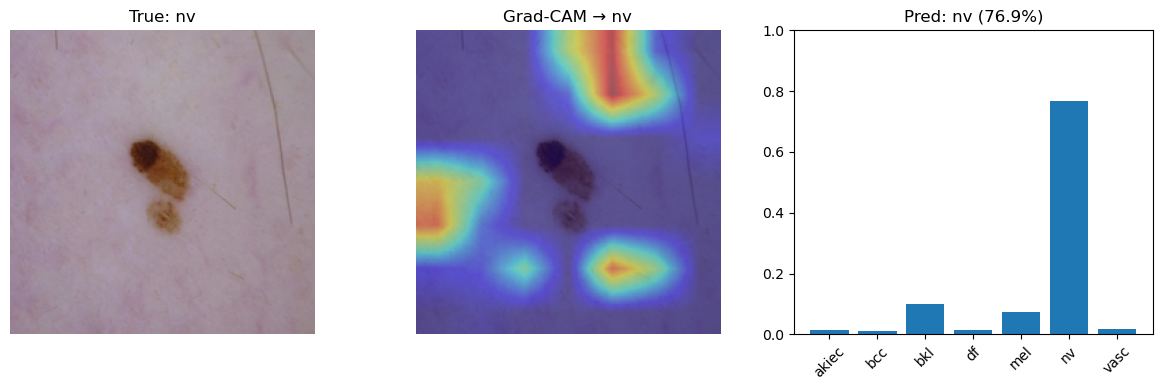

[TEST] True: nv | Pred: nv | Confidence: 76.91% | Correct: True


In [10]:
# --- Grad-CAM για οποιοδήποτε CNN (π.χ. MobileNetV3 + custom head) ---

import torch, torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# 1) Βοηθητικό: βρίσκει το τελευταίο Conv2d στο μοντέλο (target layer)
def get_last_conv_layer(module):
    last = None
    for m in module.modules():
        if isinstance(m, torch.nn.Conv2d):
            last = m
    if last is None:
        raise RuntimeError("Δεν βρέθηκε Conv2d layer στο μοντέλο!")
    return last

# 2) Υπολογισμός Grad-CAM για 1 εικόνα (tensor σχήματος [1,3,H,W])
def gradcam_on_tensor(model, x, target_layer=None, target_class=None):
    model.eval()
    if target_layer is None:
        target_layer = get_last_conv_layer(model)

    feats = []
    grads = []

    def f_hook(_, __, output):
        feats.append(output.detach())

    def b_hook(_, grad_in, grad_out):
        grads.append(grad_out[0].detach())

    h1 = target_layer.register_forward_hook(f_hook)
    h2 = target_layer.register_full_backward_hook(b_hook)  # PyTorch ≥1.10

    # forward
    logits = model(x)
    probs  = torch.softmax(logits, dim=1)
    pred_c = int(probs.argmax(dim=1).item())
    if target_class is None:
        target_class = pred_c

    # backward για 1 κλάση
    model.zero_grad()
    one_hot = torch.zeros_like(logits)
    one_hot[0, target_class] = 1.0
    logits.backward(gradient=one_hot, retain_graph=True)

    # παίρνουμε features/grads
    feat = feats[-1]          # [1, C, Hf, Wf]
    grad = grads[-1]          # [1, C, Hf, Wf]
    h1.remove(); h2.remove()

    # βάρη = global-average-pool στα gradients
    weights = grad.mean(dim=(2,3), keepdim=True)    # [1, C, 1, 1]
    cam = (weights * feat).sum(dim=1, keepdim=True) # [1, 1, Hf, Wf]
    cam = F.relu(cam)

    # κανονικοποίηση σε [0,1]
    cam = cam - cam.min()
    cam = cam / (cam.max() + 1e-6)

    # resize στο input size
    cam = F.interpolate(cam, size=x.shape[-2:], mode="bilinear", align_corners=False)
    cam = cam.squeeze().cpu().numpy()   # [H,W]

    return cam, int(target_class), probs.detach().cpu().squeeze(0).numpy()

# 3) Overlay heatmap πάνω στην εικόνα (για plotting)
def overlay_cam_on_image(img_np, cam, alpha=0.45):
    # img_np: [H,W,3] float [0,1]
    heat = plt.cm.jet(cam)[..., :3]     # colormap σε RGB
    out  = (1 - alpha) * img_np + alpha * heat
    out  = np.clip(out, 0, 1)
    return out

# 4) Demo: τραβάει τυχαία εικόνα από df_test, τρέχει Grad-CAM + bar chart proba
def demo_gradcam_random(split="test", tta=False):
    df = {"train": df_train, "val": df_val, "test": df_test}[split]

    row = df.sample(1, random_state=np.random.randint(0, 10**6)).iloc[0]
    pil = Image.open(row["filepath"]).convert("RGB")

    x = eval_tfms(pil).unsqueeze(0).to(DEVICE)

    # Προαιρετικό TTA (ίδιο με πριν, μέσος όρος 4 όψεων)
    if tta:
        with torch.no_grad():
            y = model(x)
            y += model(torch.flip(x, [-1]))
            y += model(torch.flip(x, [-2]))
            y += model(torch.rot90(x, 1, [2,3]))
        logits = y / 4.0
    else:
        with torch.no_grad():
            logits = model(x)

    probs = torch.softmax(logits, dim=1).squeeze(0).cpu().numpy()
    pred_idx = int(probs.argmax())
    pred_name = CLASS_NAMES[pred_idx]
    conf = float(probs[pred_idx])

    # Grad-CAM πάνω στην predicted class
    cam, _, _ = gradcam_on_tensor(model, x, target_class=pred_idx)

    # Plot
    img_np = np.array(pil.resize((x.shape[-1], x.shape[-2]))) / 255.0
    cam_overlay = overlay_cam_on_image(img_np, cam)

    fig = plt.figure(figsize=(12,4))
    ax1 = plt.subplot(1,3,1); ax1.imshow(img_np); ax1.set_title(f"True: {row['dx']}"); ax1.axis('off')
    ax2 = plt.subplot(1,3,2); ax2.imshow(cam_overlay); ax2.set_title(f"Grad-CAM → {pred_name}"); ax2.axis('off')
    ax3 = plt.subplot(1,3,3); ax3.bar(range(len(CLASS_NAMES)), probs)
    ax3.set_xticks(range(len(CLASS_NAMES))); ax3.set_xticklabels(CLASS_NAMES, rotation=45)
    ax3.set_ylim(0,1); ax3.set_title(f"Pred: {pred_name} ({conf*100:.1f}%)")
    plt.tight_layout(); plt.show()

    print(f"[{split.upper()}] True: {row['dx']} | Pred: {pred_name} | Confidence: {conf:.2%} | Correct: {pred_name==row['dx']}")

# === Κάλεσέ το όσες φορές θέλεις ===
demo_gradcam_random(split="test", tta=True)   # ή tta=False


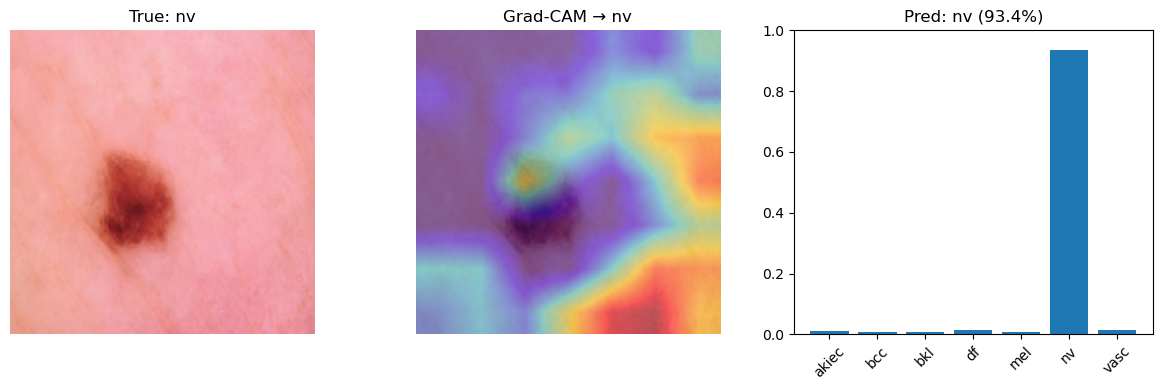

[TEST] True: nv | Pred: nv | Confidence: 93.41% | Correct: True


In [11]:
demo_gradcam_random(split="test", tta=True) 

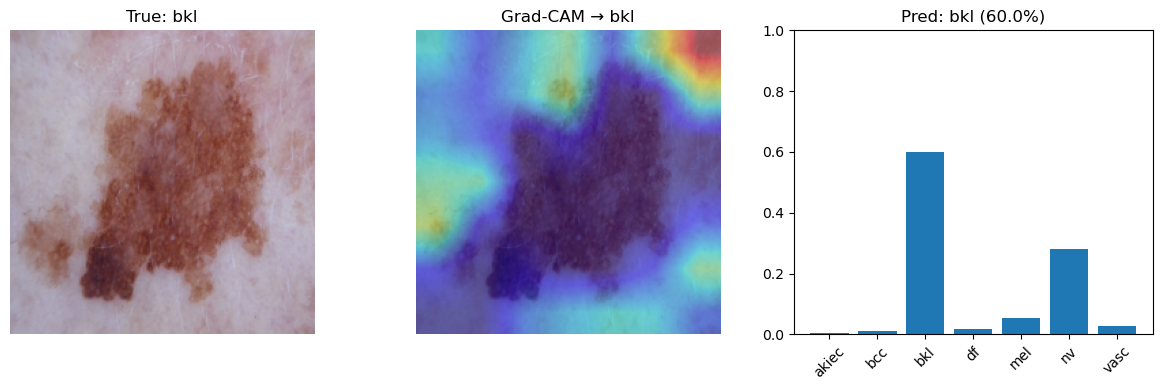

[TEST] True: bkl | Pred: bkl | Confidence: 59.99% | Correct: True


In [12]:
demo_gradcam_random(split="test", tta=True)

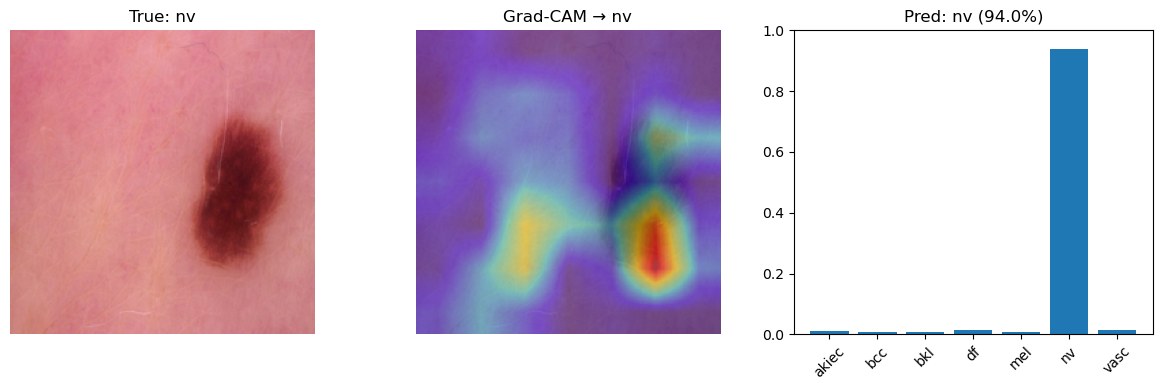

[TEST] True: nv | Pred: nv | Confidence: 93.99% | Correct: True


In [13]:
demo_gradcam_random(split="test", tta=True)

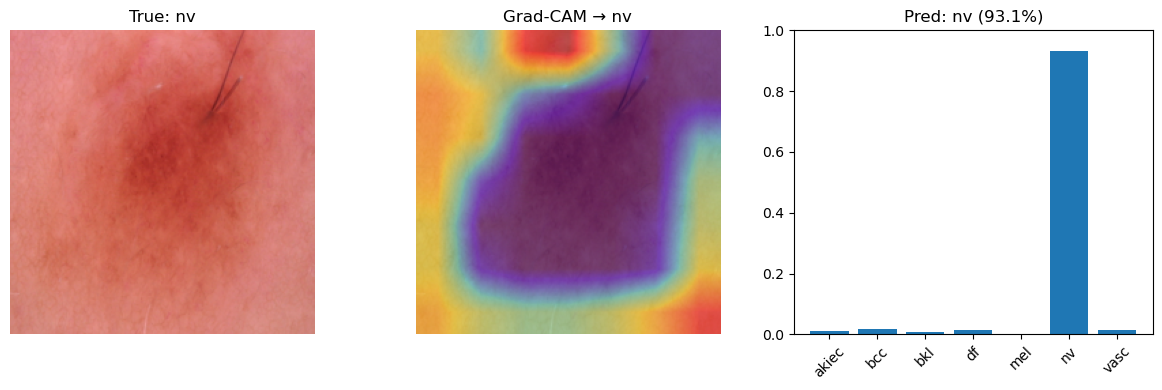

[TEST] True: nv | Pred: nv | Confidence: 93.08% | Correct: True


In [14]:
demo_gradcam_random(split="test", tta=True)

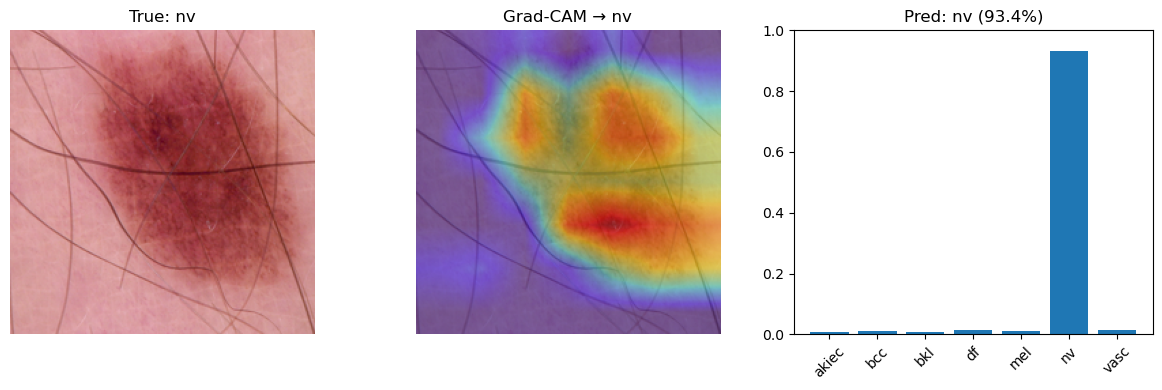

[TEST] True: nv | Pred: nv | Confidence: 93.35% | Correct: True


In [15]:
demo_gradcam_random(split="test", tta=True)

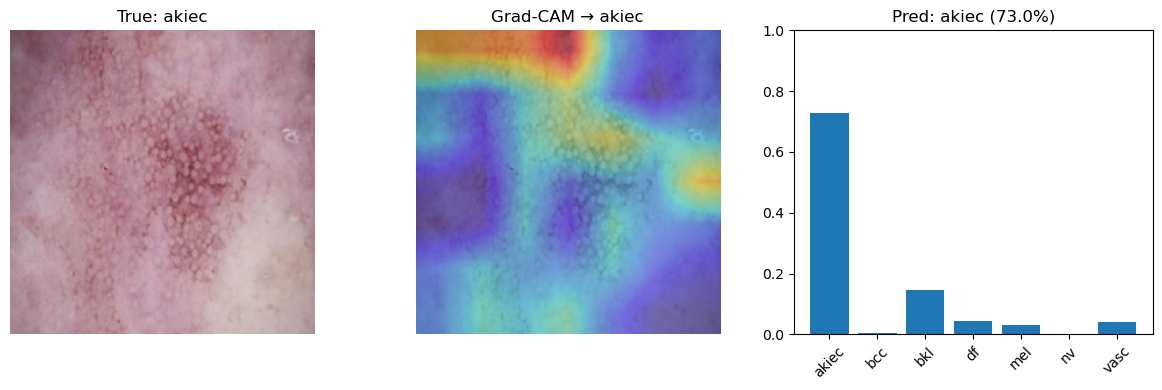

[TEST] True: akiec | Pred: akiec | Confidence: 72.96% | Correct: True


In [16]:
demo_gradcam_random(split="test", tta=True)

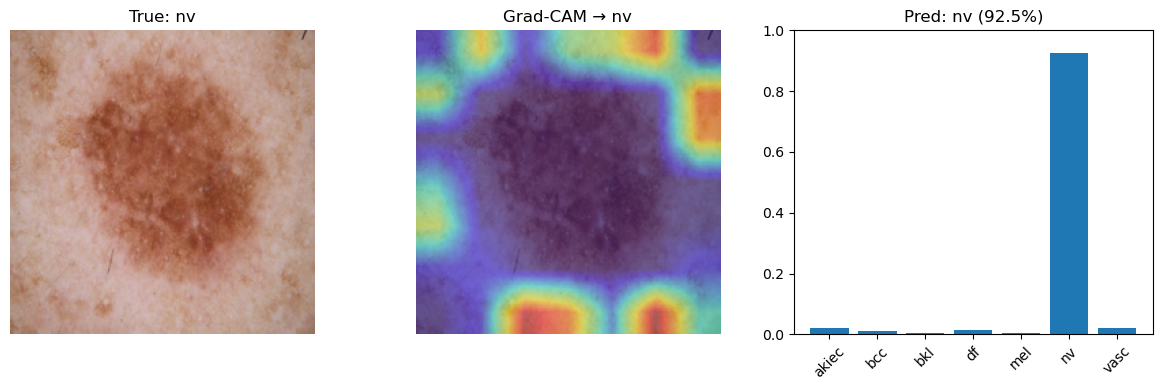

[TEST] True: nv | Pred: nv | Confidence: 92.47% | Correct: True


In [17]:
demo_gradcam_random(split="test", tta=True)

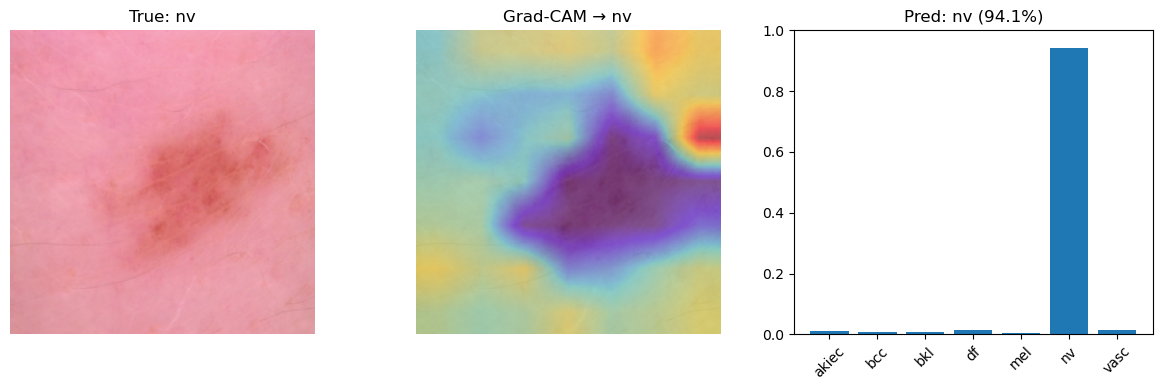

[TEST] True: nv | Pred: nv | Confidence: 94.05% | Correct: True


In [18]:
demo_gradcam_random(split="test", tta=True)

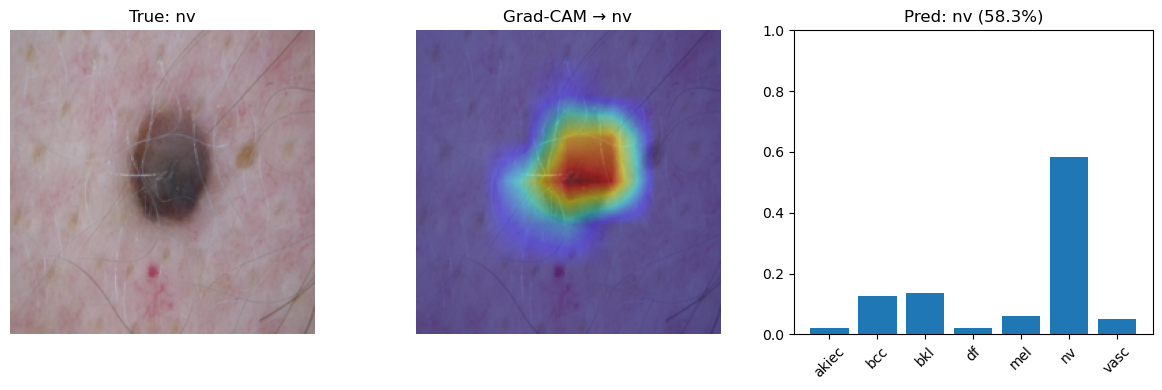

[TEST] True: nv | Pred: nv | Confidence: 58.26% | Correct: True


In [19]:
demo_gradcam_random(split="test", tta=True)

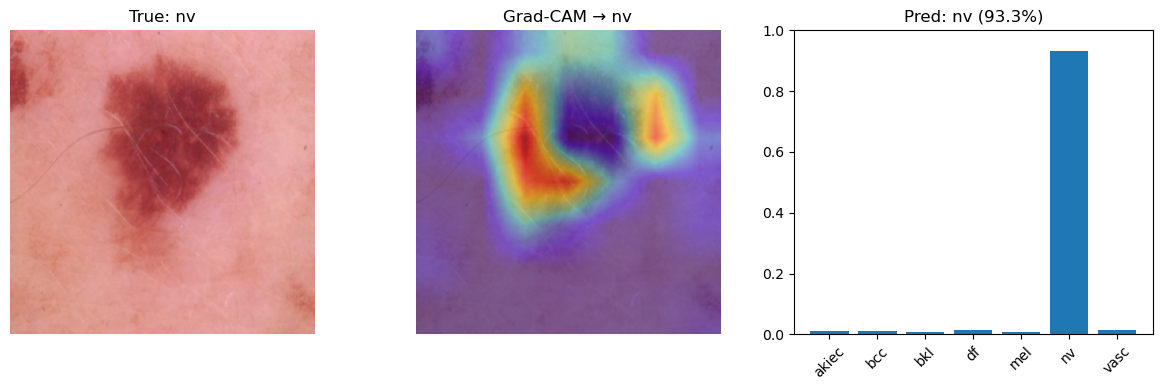

[TEST] True: nv | Pred: nv | Confidence: 93.28% | Correct: True


In [20]:
demo_gradcam_random(split="test", tta=True)

In [23]:
import torch

@torch.no_grad()
def predict_tta(x):
    """
    Test-Time Augmentation:
    original + h-flip + v-flip + rot90 -> μέσος όρος logits
    Προϋποθέτει ότι υπάρχει global μεταβλητή `model` (σε eval mode).
    """
    model.eval()
    y  = model(x)
    y += model(torch.flip(x, dims=[-1]))     # οριζόντιο flip
    y += model(torch.flip(x, dims=[-2]))     # κάθετο flip
    y += model(torch.rot90(x, k=1, dims=[2, 3]))  # 90° περιστροφή
    return y / 4


In [26]:
# ==== ΜΕΡΟΣ Β: inference σε ΜΙΑ εικόνα ====
@torch.no_grad()
def predict_image(path, tta=True):
    img = Image.open(path).convert("RGB")
    x = eval_tfms(img).unsqueeze(0).to(DEVICE)

    # Test-Time Augmentation (ίδιο concept όπως πριν)
    def predict_tta(x):
        y = 0
        y += model(x)
        y += model(torch.flip(x, [-1]))   # h-flip
        y += model(torch.flip(x, [-2]))   # v-flip
        y += model(torch.rot90(x, 1, [2,3]))  # rot90
        return y / 4

    logits = predict_tta(x) if tta else model(x)
    probs = torch.softmax(logits, dim=1).squeeze(0).cpu().numpy()

    pred_idx = int(np.argmax(probs))
    pred_name = CLASS_NAMES[pred_idx]
    conf = float(probs[pred_idx])
    dist = {c: float(p) for c, p in zip(CLASS_NAMES, probs)}
    return pred_name, conf, dist

# Παράδειγμα: δώσε μονοπάτι εικόνας
# path = r"..\data\HAM_10000_images\ISIC_0024761.jpg"
# pred, conf, dist = predict_image(path, tta=True)
# print(f"Pred: {pred} | confidence: {conf:.2%}")
# print("Distribution:", dist)

# ==== ΜΕΡΟΣ Γ: τυχαία εικόνα από το dataset (ham10000_split_v2.csv) ====
# Αν έχεις το split CSV με στήλη 'filepath', μπορείς να πάρεις τυχαίο δείγμα:
def predict_random_from_split(csv_path="ham10000_split_v2.csv", split="test", tta=True, seed=0):
    df = pd.read_csv(csv_path)
    row = df[df["split"]==split].sample(1, random_state=seed).iloc[0]
    path = row["filepath"]
    true_lbl = row["dx"]
    pred, conf, dist = predict_image(path, tta=tta)
    print(f"[{split.upper()}] True: {true_lbl} | Pred: {pred} | Confidence: {conf:.2%}")
    return path, true_lbl, pred, conf, dist

# Παράδειγμα:
# _ = predict_random_from_split("ham10000_split_v2.csv", split="test", tta=True, seed=42)

In [27]:
import os
import pandas as pd

# Βοηθητικό: φτιάχνει ΜΟΝΟ του το σωστό path μιας γραμμής
def _row_to_path(row):
    if "filepath" in row and pd.notna(row["filepath"]):
        return row["filepath"]
    if "filename" in row and pd.notna(row["filename"]):
        return os.path.join(IMAGES_DIR, row["filename"])
    if "image_id" in row and pd.notna(row["image_id"]):
        return os.path.join(IMAGES_DIR, f"{row['image_id']}.jpg")
    raise KeyError("Δεν βρέθηκε στήλη διαδρομής (filepath/filename/image_id).")

def predict_random_from_split(csv_path="ham10000_split_v2.csv", split="test", tta=True, seed=42):
    df = pd.read_csv(csv_path)
    row = df[df["split"]==split].sample(1, random_state=seed).iloc[0]
    path = _row_to_path(row)
    true_lbl = row["dx"]
    pred, conf, dist = predict_image(path, tta=tta)
    print(f"[{split.upper()}] True: {true_lbl} | Pred: {pred} | Confidence: {conf:.2%}")
    return path, true_lbl, pred, conf, dist


In [28]:
# === Helpers: βρες path από γραμμή CSV (filepath|filename|image_id) ===
import os, numpy as np, pandas as pd, torch, torch.nn.functional as F
from PIL import Image
import matplotlib.pyplot as plt
from matplotlib import cm

def _row_to_path(row):
    if "filepath" in row and pd.notna(row["filepath"]): return row["filepath"]
    if "filename" in row and pd.notna(row["filename"]): return os.path.join(IMAGES_DIR, row["filename"])
    if "image_id" in row and pd.notna(row["image_id"]): return os.path.join(IMAGES_DIR, f"{row['image_id']}.jpg")
    raise KeyError("Δεν βρέθηκε στήλη διαδρομής (filepath/filename/image_id).")

# === Inference σε ΜΙΑ εικόνα (με απλό TTA προαιρετικά) ===
@torch.no_grad()
def predict_image(path, tta=True, device=None):
    device = device or next(model.parameters()).device
    img = Image.open(path).convert("RGB")
    x = eval_tfms(img).unsqueeze(0).to(device)

    if tta:
        y  = model(x)
        y += model(torch.flip(x, [-1]))
        y += model(torch.flip(x, [-2]))
        y += model(torch.rot90(x, 1, [2,3]))
        logits = y / 4
    else:
        logits = model(x)

    probs = torch.softmax(logits, dim=1).squeeze(0).cpu().numpy()
    pred_idx = int(probs.argmax())
    pred_name = CLASS_NAMES[pred_idx]
    conf = float(probs[pred_idx])
    return img, x, probs, pred_idx, pred_name, conf

# === Quick Grad-CAM (βρίσκει μόνο του το τελευταίο Conv2d και κάνει CAM για target class) ===
def _find_last_conv(m):
    last = None
    for mod in m.modules():
        if isinstance(mod, torch.nn.Conv2d): last = mod
    if last is None: raise RuntimeError("Δεν βρέθηκε Conv2d στο μοντέλο!")
    return last

def gradcam_tensor(x, target_idx=None):
    model.eval()
    layer = _find_last_conv(model)
    feats, grads = [], []

    def f_hook(_m, _i, o): feats.append(o.detach())
    def b_hook(_m, gi, go): grads.append(go[0].detach())

    h1 = layer.register_forward_hook(f_hook)
    h2 = layer.register_full_backward_hook(b_hook)

    logits = model(x)
    probs  = torch.softmax(logits, dim=1)
    if target_idx is None:
        target_idx = int(probs.argmax(1).item())

    model.zero_grad(set_to_none=True)
    one_hot = torch.zeros_like(logits); one_hot[0, target_idx] = 1.0
    logits.backward(gradient=one_hot, retain_graph=False)

    A = feats[-1]   # [1,C,h,w]
    G = grads[-1]   # [1,C,h,w]
    h1.remove(); h2.remove()

    weights = G.mean(dim=(2,3), keepdim=True)     # [1,C,1,1]
    cam = (weights * A).sum(dim=1, keepdim=True)  # [1,1,h,w]
    cam = F.relu(cam)
    cam = F.interpolate(cam, size=x.shape[-2:], mode="bilinear", align_corners=False)
    cam = cam.squeeze().cpu().numpy()
    cam = (cam - cam.min()) / (cam.max() + 1e-8)
    return cam

def overlay_cam_on_pil(pil_img, cam, alpha=0.40):
    w, h = pil_img.size
    # το cam είναι ήδη στο σωστό μέγεθος (H,W) από τη gradcam_tensor
    heat = cm.get_cmap("jet")(cam)[...,:3]
    base = np.array(pil_img).astype(np.float32)/255.0
    out  = (1-alpha)*base + alpha*heat
    return np.clip(out, 0, 1)

# === ΜΙΑ ΚΛΗΣΗ που κάνει ΟΛΑ τα παρακάτω για ΤΥΧΑΙΑ εικόνα από το split CSV ===
def demo_random_with_cam(csv_path="ham10000_split_v2.csv", split="test", tta=True, seed=None):
    df = pd.read_csv(csv_path)
    row = df[df["split"]==split].sample(1, random_state=seed).iloc[0]
    path = _row_to_path(row)
    true_lbl = row["dx"]

    pil, x, probs, pred_idx, pred_name, conf = predict_image(path, tta=tta)
    # για σωστό overlay, κάνουμε resize την original στο input μέγεθος
    _, H, W = x.shape[1:]
    pil_resized = pil.resize((W, H))
    # CAM πάνω στην ΠΡΟΒΛΕΨΗ (όχι με TTA, τα gradients χρειάζονται ένα forward)
    cam = gradcam_tensor(x, target_idx=pred_idx)
    overlay = overlay_cam_on_pil(pil_resized, cam, alpha=0.40)

    # Plot: Original | Grad-CAM | Bar chart
    plt.figure(figsize=(12,4))
    ax1 = plt.subplot(1,3,1); ax1.imshow(pil_resized); ax1.axis('off'); ax1.set_title(f"True: {true_lbl}")
    ax2 = plt.subplot(1,3,2); ax2.imshow(overlay);     ax2.axis('off'); ax2.set_title(f"Grad-CAM → {pred_name}")
    ax3 = plt.subplot(1,3,3); ax3.bar(range(len(CLASS_NAMES)), probs); 
    ax3.set_xticks(range(len(CLASS_NAMES))); ax3.set_xticklabels(CLASS_NAMES, rotation=45, ha="right")
    ax3.set_ylim(0,1); ax3.set_title(f"Pred: {pred_name} ({conf*100:.1f}%)")
    plt.tight_layout(); plt.show()

    print(f"[{split.upper()}] True: {true_lbl} | Pred: {pred_name} | Confidence: {conf:.2%} | Correct: {pred_name==true_lbl}")
    return path, true_lbl, pred_name, conf

# === ΠΩΣ ΤΟ ΚΑΛΕΙΣ ===
# 1) Μια τυχαία εικόνα από το TEST:
# demo_random_with_cam("ham10000_split_v2.csv", split="test", tta=True, seed=None)

# 2) Αν θέλεις «αναπαραγώγιμη» τυχαιότητα, δώσε seed (π.χ. 123):
# demo_random_with_cam("ham10000_split_v2.csv", split="test", tta=True, seed=123)

# 3) Αν θέλεις από το validation:
# demo_random_with_cam("ham10000_split_v2.csv", split="val", tta=True)


C:\Users\Common\AppData\Local\Temp\ipykernel_18780\3950061419.py:78: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  heat = cm.get_cmap("jet")(cam)[...,:3]


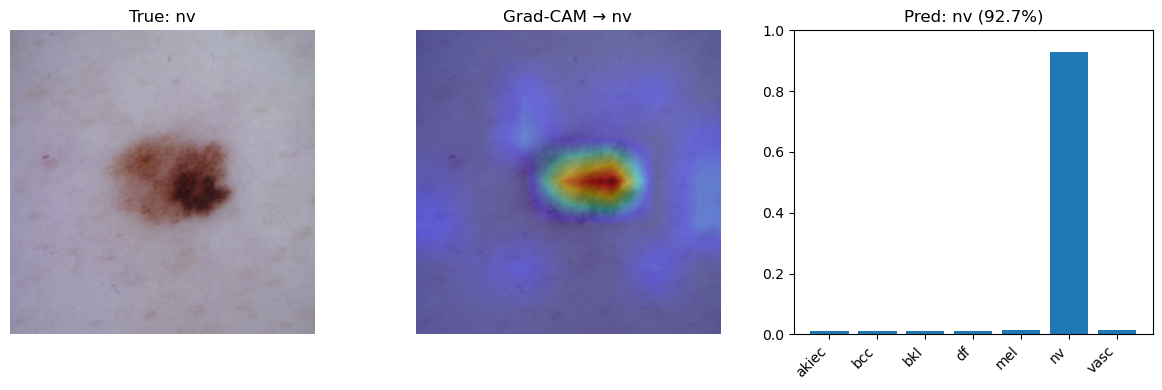

[TEST] True: nv | Pred: nv | Confidence: 92.73% | Correct: True


('..\\data\\HAM_10000_images\\ISIC_0033974.jpg',
 'nv',
 'nv',
 0.9272868633270264)

In [29]:
demo_random_with_cam("ham10000_split_v2.csv", split="test", tta=True, seed=None)

C:\Users\Common\AppData\Local\Temp\ipykernel_18780\3950061419.py:78: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  heat = cm.get_cmap("jet")(cam)[...,:3]


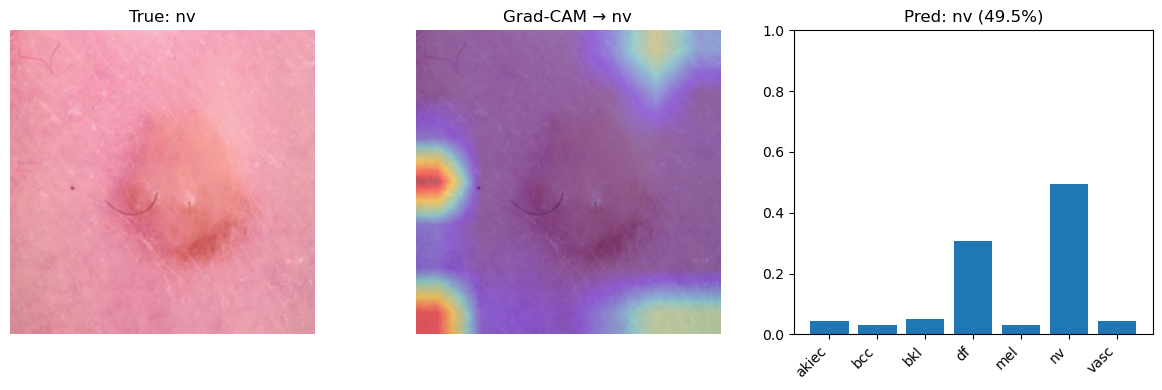

[TEST] True: nv | Pred: nv | Confidence: 49.54% | Correct: True


('..\\data\\HAM_10000_images\\ISIC_0026638.jpg',
 'nv',
 'nv',
 0.4954407215118408)

In [31]:
demo_random_with_cam("ham10000_split_v2.csv", split="test", tta=True, seed=None)